## Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
PLOT_DIR   = '/content/drive/MyDrive/insurance_fraud/plots/'
os.makedirs(PLOT_DIR, exist_ok=True)
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Cell 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.feature_selection import mutual_info_classif
import joblib

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot style
NAVY = '#0D1B3E'; CARD = '#132447'; ACCENT = '#1DB8C4'
GREEN = '#22C97A'; RED = '#E84C4C'; YELLOW = '#F5C842'
WHITE = '#FFFFFF'; GRAY = '#8BA3BF'; PURPLE = '#C87EFF'
plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': CARD,
    'axes.labelcolor': WHITE, 'xtick.color': WHITE,
    'ytick.color': WHITE, 'text.color': WHITE,
    'axes.titlecolor': WHITE, 'axes.edgecolor': ACCENT,
    'grid.color': '#1D3557', 'grid.alpha': 0.4,
})

def save_plot(fig, name):
    fig.savefig(PLOT_DIR + name, dpi=150, bbox_inches='tight', facecolor=NAVY)
    print(f'  💾 {name}')

print('✅ Imports done.')

✅ Imports done.


## Cell 3 — Load Data

In [ ]:
train = pd.read_parquet(OUTPUT_DIR + 'train_provider_merged.parquet')
test  = pd.read_parquet(OUTPUT_DIR + 'test_provider_merged.parquet')

# Drop placeholder fraud label from test if present
if 'fraud_label' in test.columns:
    test_labels_backup = test[['Provider', 'fraud_label']].copy()
    test = test.drop(columns=['fraud_label'], errors='ignore')

print(f'✅ Train: {train.shape[0]:,} providers × {train.shape[1]} features')
print(f'   Test : {test.shape[0]:,} providers × {test.shape[1]} features')
print(f'\n   Train fraud rate: {train["fraud_label"].mean()*100:.1f}%')
print(f'   Columns: {train.columns.tolist()}')

✅ Train: 5,410 providers × 34 features
   Test : 1,353 providers × 33 features

   Train fraud rate: 9.4%
   Columns: ['Provider', 'ip_claim_count', 'ip_unique_patients', 'ip_total_reimbursement', 'ip_avg_reimbursement', 'ip_max_reimbursement', 'ip_total_deductible', 'ip_avg_deductible', 'ip_avg_stay_days', 'ip_max_stay_days', 'ip_total_stay_days', 'ip_avg_patient_age', 'ip_deceased_patient_count', 'ip_avg_chronic_cond', 'ip_max_chronic_cond', 'ip_unique_attending_phys', 'ip_unique_operating_phys', 'ip_avg_annual_ip_reimb', 'ip_avg_annual_op_reimb', 'op_claim_count', 'op_unique_patients', 'op_total_reimbursement', 'op_avg_reimbursement', 'op_max_reimbursement', 'op_total_deductible', 'op_avg_patient_age', 'op_avg_chronic_cond', 'op_unique_attending_phys', 'op_avg_claim_duration', 'ip_op_claim_ratio', 'avg_reimb_per_patient', 'total_unique_patients', 'deductible_reimb_ratio', 'fraud_label']


## Cell 4 — Baseline Feature Snapshot

In [ ]:
# Separate label and provider ID before engineering
y_train = train['fraud_label'].copy()
provider_train = train['Provider'].copy()
provider_test  = test['Provider'].copy() if 'Provider' in test.columns else None

# Working copies — we'll add features to these
df_train = train.drop(columns=['fraud_label', 'Provider'], errors='ignore').copy()
df_test  = test.drop(columns=['fraud_label', 'Provider'], errors='ignore').copy()

baseline_features = df_train.columns.tolist()
print(f'Baseline features from M1: {len(baseline_features)}')
for f in baseline_features:
    print(f'  • {f}')

Baseline features from M1: 32
  • ip_claim_count
  • ip_unique_patients
  • ip_total_reimbursement
  • ip_avg_reimbursement
  • ip_max_reimbursement
  • ip_total_deductible
  • ip_avg_deductible
  • ip_avg_stay_days
  • ip_max_stay_days
  • ip_total_stay_days
  • ip_avg_patient_age
  • ip_deceased_patient_count
  • ip_avg_chronic_cond
  • ip_max_chronic_cond
  • ip_unique_attending_phys
  • ip_unique_operating_phys
  • ip_avg_annual_ip_reimb
  • ip_avg_annual_op_reimb
  • op_claim_count
  • op_unique_patients
  • op_total_reimbursement
  • op_avg_reimbursement
  • op_max_reimbursement
  • op_total_deductible
  • op_avg_patient_age
  • op_avg_chronic_cond
  • op_unique_attending_phys
  • op_avg_claim_duration
  • ip_op_claim_ratio
  • avg_reimb_per_patient
  • total_unique_patients
  • deductible_reimb_ratio


## Cell 5 — Group A: Ratio Features
> Ratios capture the *relationship* between two signals — much more powerful than raw numbers alone

In [ ]:
def add_ratio_features(df):
    """
    8 ratio features that capture fraudulent billing relationships.
    Each ratio has a specific fraud interpretation.
    """
    df = df.copy()
    eps = 1e-9  # Avoid division by zero

    # 1. Reimbursement per claim — high value = overbilling per visit
    if 'ip_total_reimbursement' in df.columns and 'ip_claim_count' in df.columns:
        df['feat_reimb_per_ip_claim'] = (
            df['ip_total_reimbursement'] / (df['ip_claim_count'] + eps)
        ).round(2)

    # 2. Reimbursement per unique patient — fraud providers extract more per person
    if 'ip_total_reimbursement' in df.columns and 'ip_unique_patients' in df.columns:
        df['feat_reimb_per_unique_patient'] = (
            df['ip_total_reimbursement'] / (df['ip_unique_patients'] + eps)
        ).round(2)

    # 3. Total reimbursement per physician used
    if 'ip_total_reimbursement' in df.columns and 'ip_unique_attending_phys' in df.columns:
        df['feat_reimb_per_physician'] = (
            df['ip_total_reimbursement'] / (df['ip_unique_attending_phys'] + eps)
        ).round(2)

    # 4. Inpatient vs outpatient patient overlap — same patients in both = suspicious
    if 'ip_unique_patients' in df.columns and 'op_unique_patients' in df.columns:
        df['feat_ip_op_patient_ratio'] = (
            df['ip_unique_patients'] / (df['op_unique_patients'] + eps)
        ).round(4)

    # 5. Deductible ratio — low deductible + high reimbursement = system gaming
    if 'ip_total_deductible' in df.columns and 'ip_total_reimbursement' in df.columns:
        df['feat_deductible_ratio'] = (
            df['ip_total_deductible'] / (df['ip_total_reimbursement'] + eps)
        ).round(4)

    # 6. Claims per unique patient — many claims per patient = repeat/duplicate billing
    if 'ip_claim_count' in df.columns and 'ip_unique_patients' in df.columns:
        df['feat_claims_per_patient'] = (
            df['ip_claim_count'] / (df['ip_unique_patients'] + eps)
        ).round(4)

    # 7. Operating physician reuse rate — same surgeon on all cases = fake procedures
    if 'ip_unique_operating_phys' in df.columns and 'ip_claim_count' in df.columns:
        df['feat_op_physician_reuse_rate'] = (
            df['ip_claim_count'] / (df['ip_unique_operating_phys'] + eps)
        ).round(4)

    # 8. Stay days per claim — normalised hospital stay
    if 'ip_total_stay_days' in df.columns and 'ip_claim_count' in df.columns:
        df['feat_stay_days_per_claim'] = (
            df['ip_total_stay_days'] / (df['ip_claim_count'] + eps)
        ).round(4)

    return df


df_train = add_ratio_features(df_train)
df_test  = add_ratio_features(df_test)

ratio_feats = [c for c in df_train.columns if c.startswith('feat_reimb') or
               c in ['feat_ip_op_patient_ratio','feat_deductible_ratio',
                     'feat_claims_per_patient','feat_op_physician_reuse_rate',
                     'feat_stay_days_per_claim']]
print(f'✅ Group A — Ratio features added: {len(ratio_feats)}')
for f in ratio_feats:
    print(f'   • {f}')

✅ Group A — Ratio features added: 8
   • feat_reimb_per_ip_claim
   • feat_reimb_per_unique_patient
   • feat_reimb_per_physician
   • feat_ip_op_patient_ratio
   • feat_deductible_ratio
   • feat_claims_per_patient
   • feat_op_physician_reuse_rate
   • feat_stay_days_per_claim


## Cell 6 — Group B: Composite Risk Scores
> Combines multiple signals into single interpretable scores — great for XAI explanations

In [ ]:
def add_risk_scores(df):
    """
    6 composite risk scores — each summarises a fraud dimension.
    Scores are normalised 0-1 using rank percentile within the dataset.
    """
    df = df.copy()

    def pct_rank(series):
        """Rank a series as percentile 0-1 (robust to outliers)"""
        return series.rank(pct=True).fillna(0)

    # 1. Financial risk score — how extreme is the billing pattern?
    fin_components = []
    for col in ['ip_avg_reimbursement', 'ip_total_reimbursement',
                'feat_reimb_per_unique_patient', 'feat_reimb_per_ip_claim']:
        if col in df.columns:
            fin_components.append(pct_rank(df[col]))
    if fin_components:
        df['risk_financial'] = pd.concat(fin_components, axis=1).mean(axis=1).round(4)

    # 2. Volume risk score — suspiciously high claim volume?
    vol_components = []
    for col in ['ip_claim_count', 'op_claim_count', 'total_unique_patients',
                'feat_claims_per_patient']:
        if col in df.columns:
            vol_components.append(pct_rank(df[col]))
    if vol_components:
        df['risk_volume'] = pd.concat(vol_components, axis=1).mean(axis=1).round(4)

    # 3. Medical complexity score — is the patient case mix realistic?
    med_components = []
    for col in ['ip_avg_chronic_cond', 'ip_max_chronic_cond',
                'ip_avg_stay_days', 'ip_avg_patient_age']:
        if col in df.columns:
            med_components.append(pct_rank(df[col]))
    if med_components:
        df['risk_medical_complexity'] = pd.concat(med_components, axis=1).mean(axis=1).round(4)

    # 4. Physician pattern risk — unusual physician usage patterns?
    phys_components = []
    for col in ['ip_unique_attending_phys', 'ip_unique_operating_phys',
                'feat_op_physician_reuse_rate', 'op_unique_attending_phys']:
        if col in df.columns:
            phys_components.append(pct_rank(df[col]))
    if phys_components:
        df['risk_physician_pattern'] = pd.concat(phys_components, axis=1).mean(axis=1).round(4)

    # 5. Stay duration risk — inflated hospital stays?
    stay_components = []
    for col in ['ip_avg_stay_days', 'ip_max_stay_days',
                'ip_total_stay_days', 'feat_stay_days_per_claim']:
        if col in df.columns:
            stay_components.append(pct_rank(df[col]))
    if stay_components:
        df['risk_stay_duration'] = pd.concat(stay_components, axis=1).mean(axis=1).round(4)

    # 6. COMPOSITE overall fraud risk score — weighted average of all 5 dimensions
    risk_cols = [c for c in ['risk_financial', 'risk_volume', 'risk_medical_complexity',
                              'risk_physician_pattern', 'risk_stay_duration']
                 if c in df.columns]
    if risk_cols:
        # Financial and volume signals weighted higher (stronger predictors)
        weights = {'risk_financial': 2.0, 'risk_volume': 1.5,
                   'risk_medical_complexity': 1.0, 'risk_physician_pattern': 1.2,
                   'risk_stay_duration': 1.3}
        weighted_sum = sum(df[c] * weights.get(c, 1.0) for c in risk_cols)
        total_weight = sum(weights.get(c, 1.0) for c in risk_cols)
        df['risk_composite_score'] = (weighted_sum / total_weight).round(4)

    return df


df_train = add_risk_scores(df_train)
df_test  = add_risk_scores(df_test)

risk_feats = [c for c in df_train.columns if c.startswith('risk_')]
print(f'✅ Group B — Risk score features added: {len(risk_feats)}')
for f in risk_feats:
    print(f'   • {f}')

# Sanity check: composite score should be higher for fraud
if 'risk_composite_score' in df_train.columns:
    fraud_mask = y_train == 1
    print(f'\n   Composite score — Non-fraud avg: {df_train.loc[~fraud_mask, "risk_composite_score"].mean():.3f}')
    print(f'   Composite score — Fraud avg    : {df_train.loc[fraud_mask,  "risk_composite_score"].mean():.3f}')
    print('   ↑ Fraud should be higher — if not, check M1 data merge')

✅ Group B — Risk score features added: 6
   • risk_financial
   • risk_volume
   • risk_medical_complexity
   • risk_physician_pattern
   • risk_stay_duration
   • risk_composite_score

   Composite score — Non-fraud avg: 0.471
   Composite score — Fraud avg    : 0.786
   ↑ Fraud should be higher — if not, check M1 data merge


## Cell 7 — Group C: Interaction Features
> Feature crosses amplify signals that are weak individually but strong together

In [ ]:
def add_interaction_features(df):
    """
    8 interaction features — multiplicative combinations of fraud signals.
    Logic: a provider who is high on BOTH volume AND reimbursement is
    far more suspicious than one who is high on just one.
    """
    df = df.copy()
    eps = 1e-9

    # 1. High volume × high reimbursement = classic billing mill signal
    if 'ip_claim_count' in df.columns and 'ip_avg_reimbursement' in df.columns:
        df['interact_volume_x_reimb'] = (
            np.log1p(df['ip_claim_count']) * np.log1p(df['ip_avg_reimbursement'])
        ).round(4)

    # 2. Many patients × high chronic score = diagnosis stuffing at scale
    if 'total_unique_patients' in df.columns and 'ip_avg_chronic_cond' in df.columns:
        df['interact_patients_x_chronic'] = (
            np.log1p(df['total_unique_patients']) * df['ip_avg_chronic_cond']
        ).round(4)

    # 3. Long stays × high reimbursement = inflated inpatient overbilling
    if 'ip_avg_stay_days' in df.columns and 'ip_avg_reimbursement' in df.columns:
        df['interact_stay_x_reimb'] = (
            df['ip_avg_stay_days'] * np.log1p(df['ip_avg_reimbursement'])
        ).round(4)

    # 4. Many physicians × many patients = scattered/fake claim network
    if 'ip_unique_attending_phys' in df.columns and 'total_unique_patients' in df.columns:
        df['interact_physicians_x_patients'] = (
            np.log1p(df['ip_unique_attending_phys']) *
            np.log1p(df['total_unique_patients'])
        ).round(4)

    # 5. Low deductible + high reimbursement (both extreme together)
    if 'feat_deductible_ratio' in df.columns and 'ip_total_reimbursement' in df.columns:
        # Invert deductible ratio so high = suspicious (low deductible)
        inv_ded = 1 / (df['feat_deductible_ratio'] + eps)
        df['interact_low_deductible_x_high_reimb'] = (
            inv_ded * np.log1p(df['ip_total_reimbursement'])
        ).clip(0, 1e6).round(4)

    # 6. Financial risk × physician pattern risk
    if 'risk_financial' in df.columns and 'risk_physician_pattern' in df.columns:
        df['interact_financial_x_physician'] = (
            df['risk_financial'] * df['risk_physician_pattern']
        ).round(4)

    # 7. Volume risk × stay duration risk
    if 'risk_volume' in df.columns and 'risk_stay_duration' in df.columns:
        df['interact_volume_x_stay'] = (
            df['risk_volume'] * df['risk_stay_duration']
        ).round(4)

    # 8. Composite score squared — amplifies extreme providers
    if 'risk_composite_score' in df.columns:
        df['interact_composite_squared'] = (
            df['risk_composite_score'] ** 2
        ).round(4)

    return df


df_train = add_interaction_features(df_train)
df_test  = add_interaction_features(df_test)

interact_feats = [c for c in df_train.columns if c.startswith('interact_')]
print(f'✅ Group C — Interaction features added: {len(interact_feats)}')
for f in interact_feats:
    print(f'   • {f}')

✅ Group C — Interaction features added: 8
   • interact_volume_x_reimb
   • interact_patients_x_chronic
   • interact_stay_x_reimb
   • interact_physicians_x_patients
   • interact_low_deductible_x_high_reimb
   • interact_financial_x_physician
   • interact_volume_x_stay
   • interact_composite_squared


## Cell 8 — Group D: Z-Score Deviation Features
> How many standard deviations is this provider away from average? Extreme z-scores = anomalous behaviour

In [ ]:
def add_zscore_features(df_train, df_test):
    """
    Computes z-scores using TRAIN statistics only (no data leakage).
    Applied to both train and test.
    """
    zscore_cols = [
        'ip_avg_reimbursement',
        'ip_total_reimbursement',
        'total_unique_patients',
        'ip_avg_stay_days',
        'ip_avg_chronic_cond',
        'ip_claim_count',
        'feat_reimb_per_unique_patient',
    ]
    zscore_cols = [c for c in zscore_cols if c in df_train.columns]

    train_means = df_train[zscore_cols].mean()
    train_stds  = df_train[zscore_cols].std().replace(0, 1)  # Avoid div by zero

    df_train = df_train.copy()
    df_test  = df_test.copy()

    for col in zscore_cols:
        feat_name = f'zscore_{col}'
        df_train[feat_name] = ((df_train[col] - train_means[col]) / train_stds[col]).round(4)
        df_test[feat_name]  = ((df_test[col]  - train_means[col]) / train_stds[col]).round(4)

    # Absolute z-score — magnitude of deviation regardless of direction
    zscore_feat_names = [f'zscore_{c}' for c in zscore_cols]
    df_train['feat_max_abs_zscore'] = df_train[zscore_feat_names].abs().max(axis=1).round(4)
    df_test['feat_max_abs_zscore']  = df_test[zscore_feat_names].abs().max(axis=1).round(4)

    return df_train, df_test, zscore_feat_names


df_train, df_test, zscore_feats = add_zscore_features(df_train, df_test)

print(f'✅ Group D — Z-score features added: {len(zscore_feats) + 1}')
for f in zscore_feats:
    print(f'   • {f}')
print(f'   • feat_max_abs_zscore')

✅ Group D — Z-score features added: 8
   • zscore_ip_avg_reimbursement
   • zscore_ip_total_reimbursement
   • zscore_total_unique_patients
   • zscore_ip_avg_stay_days
   • zscore_ip_avg_chronic_cond
   • zscore_ip_claim_count
   • zscore_feat_reimb_per_unique_patient
   • feat_max_abs_zscore


## Cell 9 — Group E: Hard Anomaly Flag Features
> Binary flags: 1 if provider is in the extreme tail of a distribution, 0 otherwise

In [ ]:
def add_anomaly_flags(df_train, df_test):
    """
    Binary anomaly flags using TRAIN thresholds (95th percentile).
    These are interpretable hard rules — useful for the XAI explanation layer.
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()

    flag_configs = [
        # (column, threshold_percentile, flag_name, description)
        ('ip_avg_reimbursement',        95, 'flag_extreme_reimb',
         'Avg IP reimbursement in top 5%'),
        ('ip_claim_count',              95, 'flag_extreme_claim_volume',
         'IP claim count in top 5%'),
        ('total_unique_patients',       95, 'flag_extreme_patient_count',
         'Unique patient count in top 5%'),
        ('ip_avg_stay_days',            95, 'flag_extreme_stay_duration',
         'Avg stay duration in top 5%'),
        ('ip_avg_chronic_cond',         95, 'flag_extreme_chronic',
         'Avg chronic conditions in top 5%'),
        ('feat_reimb_per_unique_patient',95,'flag_extreme_reimb_per_patient',
         'Reimbursement per patient in top 5%'),
        ('ip_unique_attending_phys',    95, 'flag_extreme_physician_count',
         'Unique physician count in top 5%'),
        ('feat_deductible_ratio',        5, 'flag_very_low_deductible',
         'Deductible ratio in bottom 5% (very low deductible = gaming)'),
    ]

    flag_descriptions = {}
    for col, pct, flag_name, desc in flag_configs:
        if col not in df_train.columns:
            continue
        threshold = df_train[col].quantile(pct / 100)
        if pct >= 50:  # Upper tail flag
            df_train[flag_name] = (df_train[col] > threshold).astype(int)
            df_test[flag_name]  = (df_test[col]  > threshold).astype(int)
        else:          # Lower tail flag
            df_train[flag_name] = (df_train[col] < threshold).astype(int)
            df_test[flag_name]  = (df_test[col]  < threshold).astype(int)
        flag_descriptions[flag_name] = {'desc': desc, 'threshold': round(threshold, 2)}

    # Sum of all flags — providers triggering many flags are most suspicious
    flag_names = [fc[2] for fc in flag_configs if fc[0] in df_train.columns]
    df_train['feat_total_flags_triggered'] = df_train[flag_names].sum(axis=1)
    df_test['feat_total_flags_triggered']  = df_test[flag_names].sum(axis=1)

    return df_train, df_test, flag_names, flag_descriptions


df_train, df_test, flag_feats, flag_desc = add_anomaly_flags(df_train, df_test)

print(f'✅ Group E — Anomaly flag features added: {len(flag_feats) + 1}')
for f in flag_feats:
    info = flag_desc.get(f, {})
    print(f'   • {f:<40}  threshold={info.get("threshold", "N/A")}')
print(f'   • feat_total_flags_triggered')

# Sanity check: fraud providers should trigger more flags
fraud_mask = y_train == 1
nf_flags = df_train.loc[~fraud_mask, 'feat_total_flags_triggered'].mean()
f_flags  = df_train.loc[fraud_mask,  'feat_total_flags_triggered'].mean()
print(f'\n   Avg flags triggered — Non-fraud: {nf_flags:.2f}  |  Fraud: {f_flags:.2f}')

✅ Group E — Anomaly flag features added: 9
   • flag_extreme_reimb                        threshold=14000.0
   • flag_extreme_claim_volume                 threshold=39.0
   • flag_extreme_patient_count                threshold=266.55
   • flag_extreme_stay_duration                threshold=7.72
   • flag_extreme_chronic                      threshold=6.5
   • flag_extreme_reimb_per_patient            threshold=15000.0
   • flag_extreme_physician_count              threshold=11.0
   • flag_very_low_deductible                  threshold=0.0
   • feat_total_flags_triggered

   Avg flags triggered — Non-fraud: 0.25  |  Fraud: 1.17


## Cell 10 — Group F: Quantile Bin Features
> Discretise continuous features into risk tiers — helps tree models find non-linear thresholds

In [ ]:
def add_bin_features(df_train, df_test):
    """
    Bins key features into 5 quantile risk tiers (0=lowest, 4=highest).
    Uses TRAIN quantile boundaries applied to test (no leakage).
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()

    bin_cols = [
        'ip_avg_reimbursement',
        'ip_claim_count',
        'total_unique_patients',
        'ip_avg_stay_days',
        'ip_avg_chronic_cond',
        'feat_reimb_per_unique_patient',
    ]
    bin_cols = [c for c in bin_cols if c in df_train.columns]

    for col in bin_cols:
        bin_name = f'bin_{col}'
        # Compute bin edges from training data
        _, edges = pd.qcut(df_train[col], q=5, retbins=True, duplicates='drop')
        edges[0]  = -np.inf
        edges[-1] =  np.inf
        df_train[bin_name] = pd.cut(df_train[col], bins=edges, labels=False).fillna(0).astype(int)
        df_test[bin_name]  = pd.cut(df_test[col],  bins=edges, labels=False).fillna(0).astype(int)

    return df_train, df_test


df_train, df_test = add_bin_features(df_train, df_test)

bin_feats = [c for c in df_train.columns if c.startswith('bin_')]
print(f'✅ Group F — Bin features added: {len(bin_feats)}')
for f in bin_feats:
    print(f'   • {f}')

✅ Group F — Bin features added: 6
   • bin_ip_avg_reimbursement
   • bin_ip_claim_count
   • bin_total_unique_patients
   • bin_ip_avg_stay_days
   • bin_ip_avg_chronic_cond
   • bin_feat_reimb_per_unique_patient


## Cell 11 — Final Feature Set Summary

In [ ]:
# Ensure numeric only, fill any remaining NaNs
df_train = df_train.apply(pd.to_numeric, errors='coerce').fillna(0)
df_test  = df_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Replace inf values
df_train.replace([np.inf, -np.inf], 0, inplace=True)
df_test.replace([np.inf, -np.inf],  0, inplace=True)

all_features = df_train.columns.tolist()

feature_groups = {
    'A. Baseline (from M1)' : [f for f in all_features if not any(
        f.startswith(p) for p in ['feat_','risk_','interact_','zscore_','flag_','bin_'])],
    'B. Ratio features'     : [f for f in all_features if f.startswith('feat_') and 'risk' not in f
                                and 'flag' not in f and 'zscore' not in f],
    'C. Risk scores'        : [f for f in all_features if f.startswith('risk_')],
    'D. Interaction features': [f for f in all_features if f.startswith('interact_')],
    'E. Z-score features'   : [f for f in all_features if f.startswith('zscore_')],
    'F. Anomaly flags'      : [f for f in all_features if f.startswith('flag_')],
    'G. Bin features'       : [f for f in all_features if f.startswith('bin_')],
}

print('='*65)
print('  M3 FEATURE ENGINEERING SUMMARY')
print('='*65)
total = 0
for group, feats in feature_groups.items():
    print(f'\n  {group}  ({len(feats)} features)')
    for f in feats:
        print(f'    • {f}')
    total += len(feats)
print(f'\n  {'─'*40}')
print(f'  TOTAL FEATURES: {total}')
print(f'  Train shape   : {df_train.shape}')
print(f'  Test  shape   : {df_test.shape}')
print(f'  Null values   : {df_train.isnull().sum().sum()}')
print('='*65)

  M3 FEATURE ENGINEERING SUMMARY

  A. Baseline (from M1)  (32 features)
    • ip_claim_count
    • ip_unique_patients
    • ip_total_reimbursement
    • ip_avg_reimbursement
    • ip_max_reimbursement
    • ip_total_deductible
    • ip_avg_deductible
    • ip_avg_stay_days
    • ip_max_stay_days
    • ip_total_stay_days
    • ip_avg_patient_age
    • ip_deceased_patient_count
    • ip_avg_chronic_cond
    • ip_max_chronic_cond
    • ip_unique_attending_phys
    • ip_unique_operating_phys
    • ip_avg_annual_ip_reimb
    • ip_avg_annual_op_reimb
    • op_claim_count
    • op_unique_patients
    • op_total_reimbursement
    • op_avg_reimbursement
    • op_max_reimbursement
    • op_total_deductible
    • op_avg_patient_age
    • op_avg_chronic_cond
    • op_unique_attending_phys
    • op_avg_claim_duration
    • ip_op_claim_ratio
    • avg_reimb_per_patient
    • total_unique_patients
    • deductible_reimb_ratio

  B. Ratio features  (8 features)
    • feat_reimb_per_ip_claim
    • fea

## Cell 12 — Mutual Information Feature Importance

📊 Computing mutual information scores (takes ~30 seconds)...

Top 20 features by Mutual Information with fraud_label:
                       feature  mi_score
        interact_volume_x_stay    0.1299
    interact_composite_squared    0.1251
          risk_composite_score    0.1236
            ip_total_stay_days    0.1230
 zscore_ip_total_reimbursement    0.1230
        ip_total_reimbursement    0.1197
         zscore_ip_claim_count    0.1169
       interact_volume_x_reimb    0.1149
              ip_max_stay_days    0.1143
                ip_claim_count    0.1135
            ip_unique_patients    0.1118
           ip_total_deductible    0.1115
                   risk_volume    0.1104
           feat_max_abs_zscore    0.1052
  feat_op_physician_reuse_rate    0.0980
      feat_reimb_per_physician    0.0945
            risk_stay_duration    0.0928
interact_financial_x_physician    0.0923
          ip_max_reimbursement    0.0919
       zscore_ip_avg_stay_days    0.0914
  💾 plot_M3_feature_i

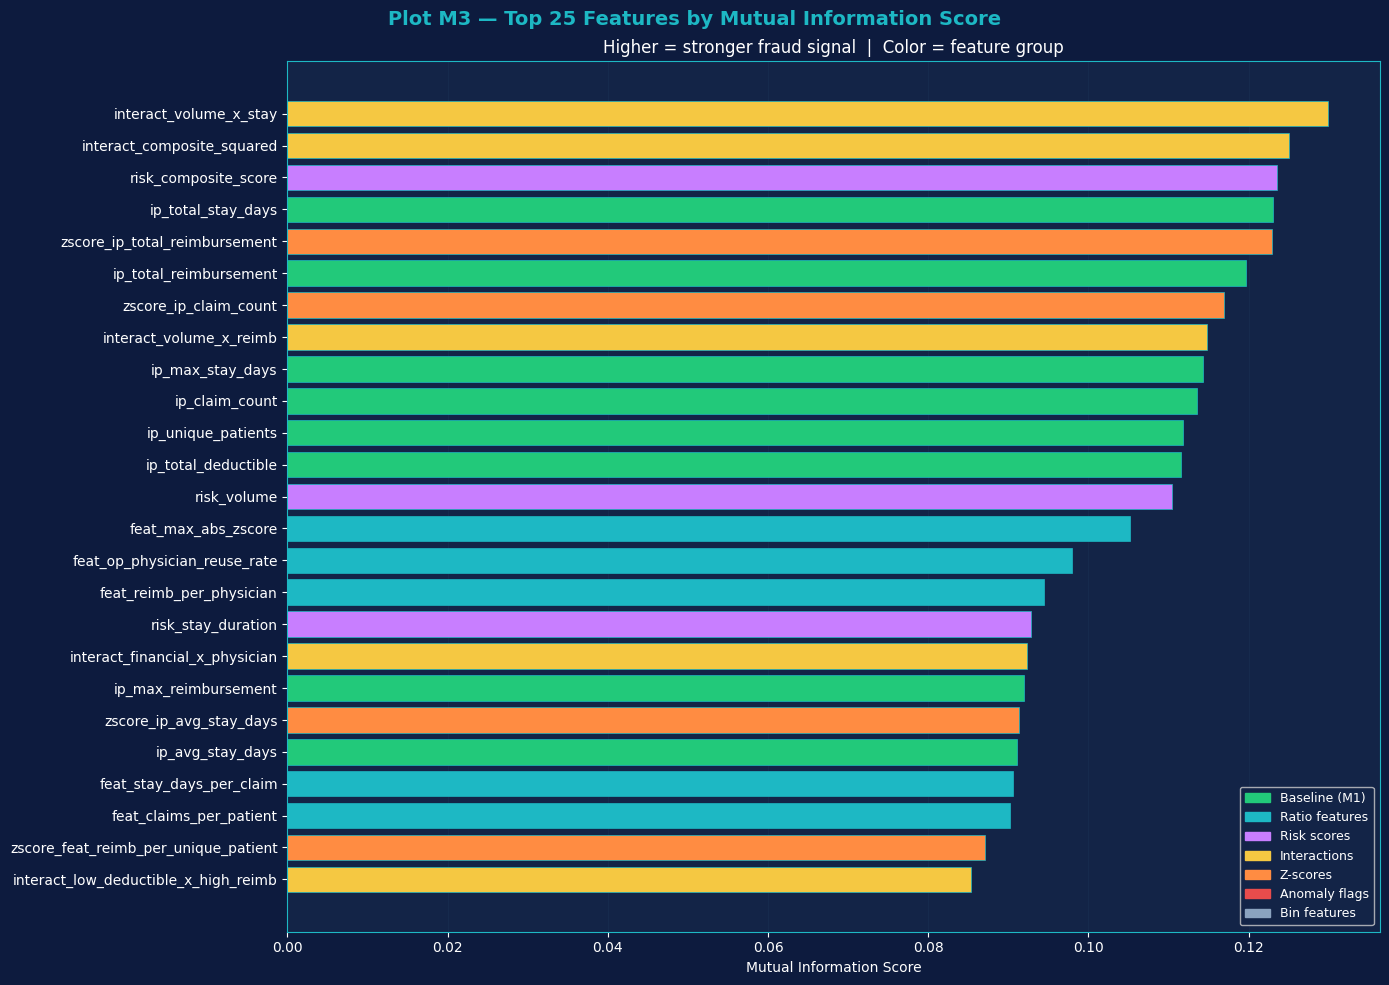

In [ ]:
print('📊 Computing mutual information scores (takes ~30 seconds)...')

mi_scores = mutual_info_classif(
    df_train, y_train,
    discrete_features='auto',
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'feature': df_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print('\nTop 20 features by Mutual Information with fraud_label:')
print(mi_df.head(20).to_string(index=False))

# Plot top 25
top25 = mi_df.head(25)
colors = []
for f in top25['feature']:
    if f.startswith('risk_'):     colors.append('#C87EFF')
    elif f.startswith('interact_'): colors.append('#F5C842')
    elif f.startswith('feat_'):   colors.append('#1DB8C4')
    elif f.startswith('flag_'):   colors.append('#E84C4C')
    elif f.startswith('zscore_'): colors.append('#FF8C42')
    elif f.startswith('bin_'):    colors.append('#8BA3BF')
    else:                          colors.append('#22C97A')

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Plot M3 — Top 25 Features by Mutual Information Score',
             fontsize=14, fontweight='bold', color=ACCENT)

bars = ax.barh(top25['feature'][::-1], top25['mi_score'][::-1],
               color=colors[::-1], edgecolor=ACCENT, linewidth=0.5)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Higher = stronger fraud signal  |  Color = feature group')
ax.xaxis.grid(True); ax.set_axisbelow(True)

# Legend
import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color='#22C97A', label='Baseline (M1)'),
    mpatches.Patch(color='#1DB8C4', label='Ratio features'),
    mpatches.Patch(color='#C87EFF', label='Risk scores'),
    mpatches.Patch(color='#F5C842', label='Interactions'),
    mpatches.Patch(color='#FF8C42', label='Z-scores'),
    mpatches.Patch(color='#E84C4C', label='Anomaly flags'),
    mpatches.Patch(color='#8BA3BF', label='Bin features'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)

plt.tight_layout()
save_plot(fig, 'plot_M3_feature_importance_MI.png')
plt.show()

## Cell 13 — Select Final Feature Set

In [ ]:
# Option 1: Use ALL engineered features (recommended — let the model decide)
# Option 2: Use top-N by MI score (use this if Colab runs out of memory)

USE_TOP_N = False   # Set True to limit to top features
TOP_N     = 40      # Only used if USE_TOP_N = True

if USE_TOP_N:
    final_features = mi_df.head(TOP_N)['feature'].tolist()
    print(f'✅ Using top {TOP_N} features by MI score')
else:
    # Drop near-zero MI features (threshold = 0.001)
    useful_features = mi_df[mi_df['mi_score'] > 0.001]['feature'].tolist()
    final_features  = useful_features
    dropped = len(all_features) - len(final_features)
    print(f'✅ Using all features with MI > 0.001')
    print(f'   Dropped {dropped} near-zero MI features')

print(f'   Final feature count: {len(final_features)}')

X_train_final = df_train[final_features].copy()
X_test_final  = df_test[[f for f in final_features if f in df_test.columns]].copy()

# Fill any test columns that are missing (edge case)
for col in final_features:
    if col not in X_test_final.columns:
        X_test_final[col] = 0
X_test_final = X_test_final[final_features]  # Ensure same column order

print(f'   X_train shape: {X_train_final.shape}')
print(f'   X_test  shape: {X_test_final.shape}')

✅ Using all features with MI > 0.001
   Dropped 3 near-zero MI features
   Final feature count: 74
   X_train shape: (5410, 74)
   X_test  shape: (1353, 74)


## Cell 14 — Save All Outputs to Drive

In [ ]:
print('💾 Saving engineered feature datasets...')

# 1. Train with all engineered features + label
train_out = X_train_final.copy()
train_out['fraud_label'] = y_train.values
train_out['Provider']    = provider_train.values
train_out.to_parquet(OUTPUT_DIR + 'train_features_engineered.parquet', index=False)
print(f'  ✅ train_features_engineered.parquet  ({train_out.shape})')

# 2. Test with all engineered features
test_out = X_test_final.copy()
if provider_test is not None:
    test_out['Provider'] = provider_test.values
test_out.to_parquet(OUTPUT_DIR + 'test_features_engineered.parquet', index=False)
print(f'  ✅ test_features_engineered.parquet   ({test_out.shape})')

# 3. Feature list with MI scores (used in M5 XAI notebook)
mi_df.to_json(OUTPUT_DIR + 'feature_importance_MI.json', orient='records', indent=2)
print(f'  ✅ feature_importance_MI.json')

# 4. Final feature column names list (for M4 to load cleanly)
with open(OUTPUT_DIR + 'final_feature_columns.json', 'w') as f:
    json.dump(final_features, f, indent=2)
print(f'  ✅ final_feature_columns.json  ({len(final_features)} features)')

# 5. Flag descriptions (for XAI natural language explanations in M5)
with open(OUTPUT_DIR + 'flag_descriptions.json', 'w') as f:
    json.dump(flag_desc, f, indent=2)
print(f'  ✅ flag_descriptions.json')



💾 Saving engineered feature datasets...
  ✅ train_features_engineered.parquet  ((5410, 76))
  ✅ test_features_engineered.parquet   ((1353, 75))
  ✅ feature_importance_MI.json
  ✅ final_feature_columns.json  (74 features)
  ✅ flag_descriptions.json
